# Parte 1 - K-Means Clustering Básico

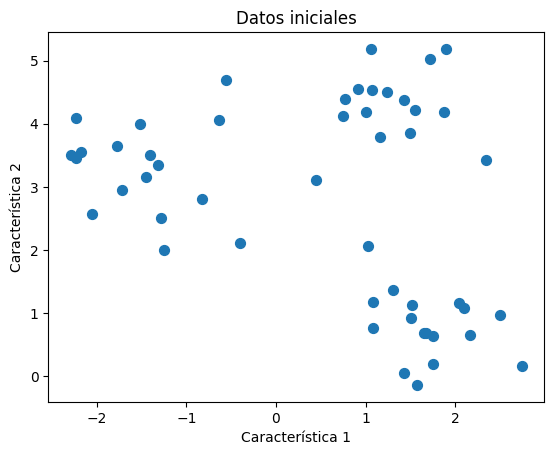

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


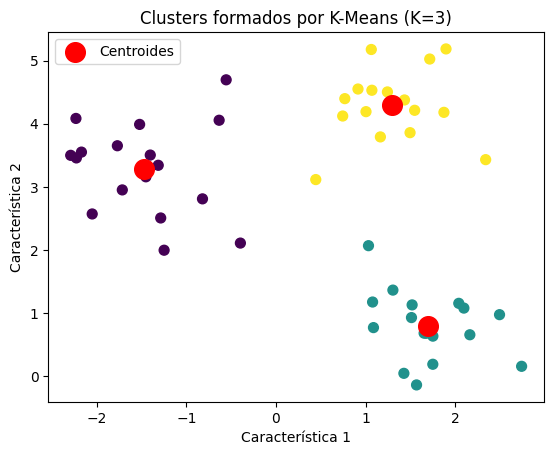

In [ ]:
# Importamos las bibliotecas necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Generación de datos simples para el clustering
np.random.seed(42)
X, y = make_blobs(n_samples=50, centers=3, cluster_std=0.60, random_state=0)

# Visualización inicial de los datos
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title('Datos iniciales')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()

# Aplicación de K-Means con 3 clusters (inicialmente)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# Asignación de los clusters a las muestras
y_kmeans = kmeans.predict(X)

# Visualización de los clusters formados
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')  # Coloreamos los puntos según su cluster
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', label='Centroides')
plt.title('Clusters formados por K-Means (K=3)')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.legend()
plt.show()

Explicación:

* K-Means: Aplicamos el algoritmo K-Means con 3 clusters inicialmente.
* Visualización: Mostramos los puntos coloreados por su cluster asignado y los centroides en rojo.

In [ ]:
kmeans.cluster_centers_

array([[-1.4748745 ,  3.29022605],
       [ 1.69842234,  0.79718251],
       [ 1.29419143,  4.29062657]])

Podemos observar los centroides que tiene cada uno de los clusters

In [ ]:
import pandas as pd
pd.DataFrame({"X": X[:,0],"Y": X[:,1], "Etiqueta": y_kmeans})

,X,Y,Etiqueta
0,1.546323,4.212973,2
1,1.674674,0.680019,1
2,1.242588,4.503992,2
3,1.164111,3.791330,2
4,-1.768810,3.651349,0
5,0.443599,3.115309,2
6,-1.520604,3.989405,0
7,-0.397014,2.109227,0
8,1.651791,0.681932,1
9,-1.285499,2.506996,0


# Parte 2 - Variación del número de clusters con K-Means

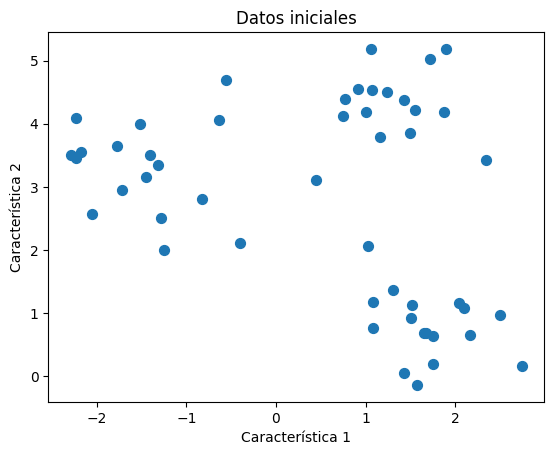

In [ ]:
# Visualización inicial de los datos
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title('Datos iniciales')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


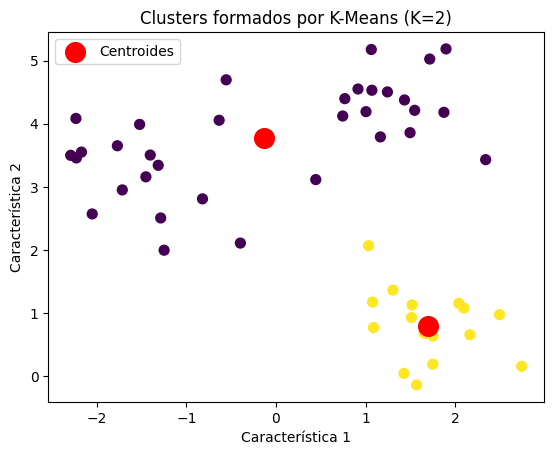

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


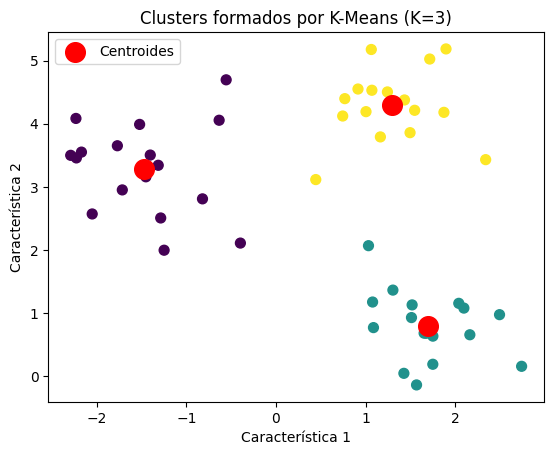

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


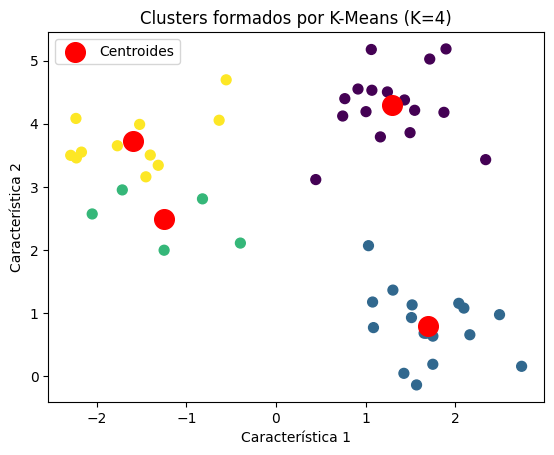

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


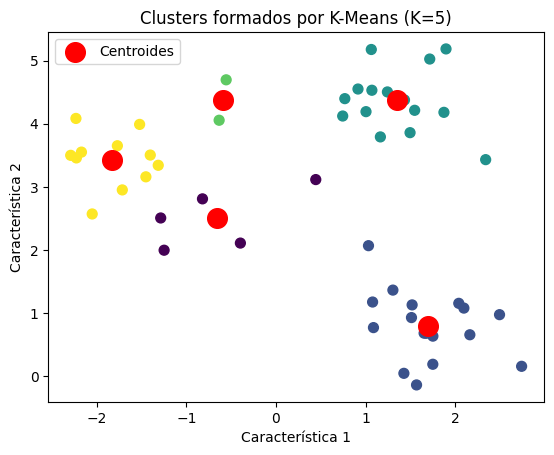

In [ ]:
# Iteramos sobre diferentes cantidades de clusters
for k in [2, 3, 4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    y_kmeans = kmeans.predict(X)

    # Visualización de los clusters formados
    plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')  # Coloreamos los puntos según su cluster
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', label='Centroides')
    plt.title(f'Clusters formados por K-Means (K={k})')
    plt.xlabel('Característica 1')
    plt.ylabel('Característica 2')
    plt.legend()
    plt.show()

Variación de K: Aplicamos K-Means con diferentes números de clusters (K=2, 3, 4, 5) para ver cómo cambia el agrupamiento.

Visualización: En cada caso, mostramos los puntos asignados a los clusters junto con sus centroides en rojo.

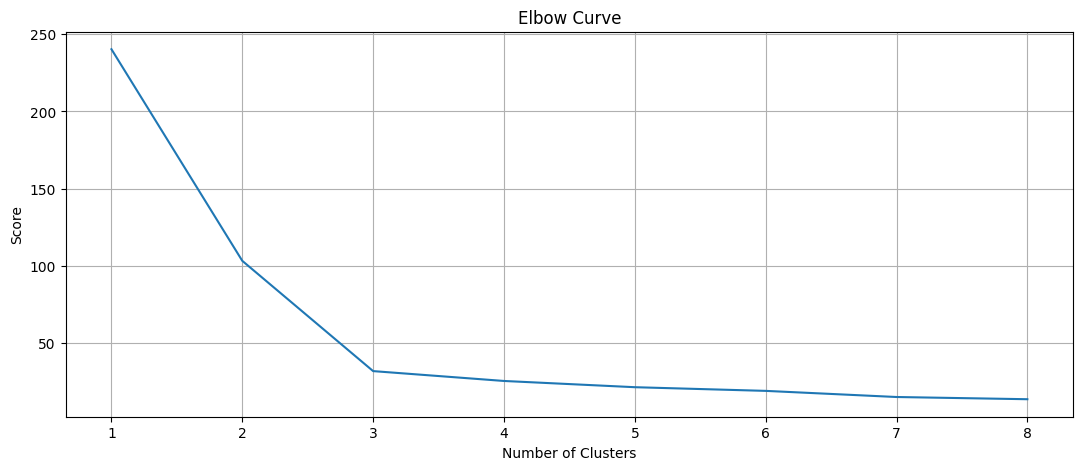

In [ ]:
#Recorremos los valores de la posible k
Nc = range(1, 9)
plt.figure(figsize= (13,5))
score = []
for i in Nc:
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=100, random_state=42)
    kmeans.fit(X)
    inercia = kmeans.inertia_
    score.append(inercia)

#Este código visualiza la curva
plt.plot(Nc,score)
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.title('Elbow Curve')
plt.grid()
plt.show()

<Figure size 1300x500 with 0 Axes>

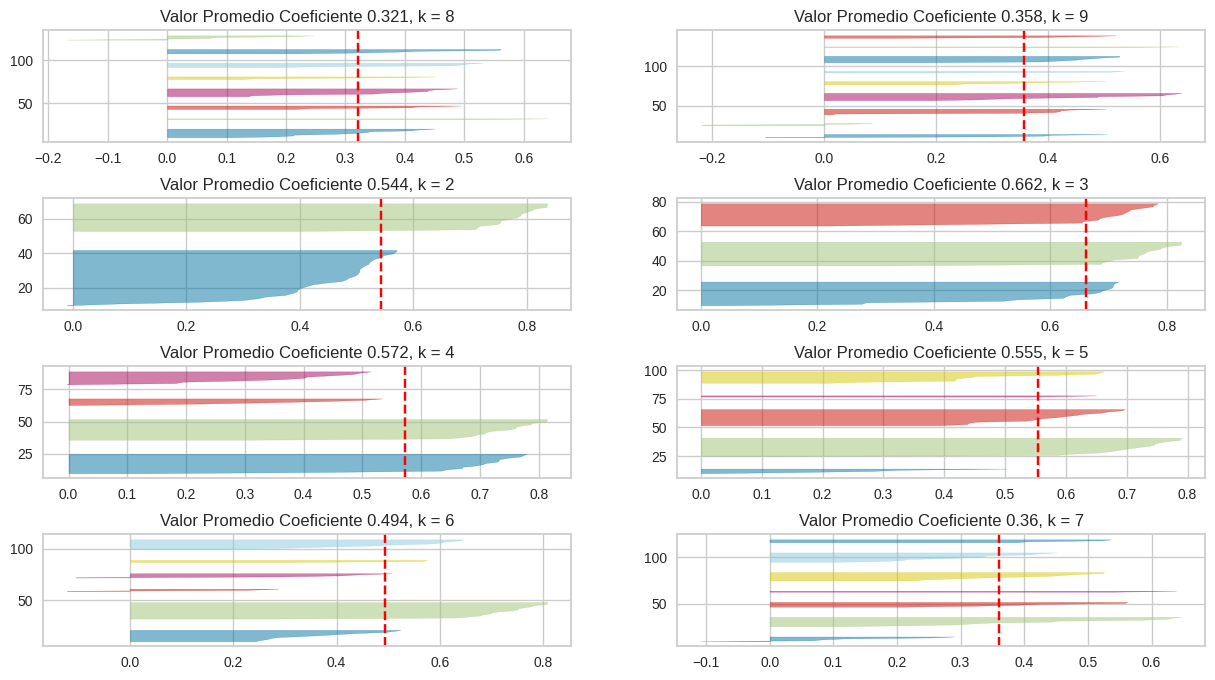

In [ ]:
from sklearn import metrics
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.metrics import silhouette_samples, silhouette_score
plt.figure(figsize= (13,5))
#instrucción que define el número de gráficas a representar y su tamaño
fig, ax = plt.subplots(4, 2, figsize=(15,8))
plt.subplots_adjust(hspace = 0.5)
for i in [2,3,4,5,6,7,8,9]:

    #Create KMeans instance for different number of clusters

    km = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=100, random_state=42)
    q, mod = divmod(i, 2)

    km.fit(X)
    score = silhouette_score(X, km.labels_, metric='euclidean')
    visualizer = SilhouetteVisualizer(km, colors='yellowbrick', ax=ax[q-4][mod])
    score = silhouette_score(X, km.labels_, metric='euclidean')
    visualizer.set_title(f"Valor Promedio Coeficiente {score:.3}, k = {i}" )
    #Fit the visualizer
    visualizer.fit(X)